In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [42]:
# Data Preparation/User performance data
user_perf = pd.read_csv("UserPerformance.csv")

# Show basic info
display(user_perf.head())
display(user_perf.describe(include="all"))
user_perf = user_perf[~user_perf["PID"].isin([2, 12])].copy()

print("After removing P2 and P12:")
display(user_perf["PID"].value_counts())




,PID,CoachingStyle,Viewpoint,Pose,FootHeight,Foot,LeftHandY,Right Hand Y,Steadiness,Mistake
0,1,Controlling Style,First Person,1,0.309592,Left,-0.276701,-0.434067,0.157366,0
1,1,Controlling Style,First Person,2,0.351130,Right,-0.273866,-0.317726,0.043860,0
2,1,Controlling Style,First Person,3,0.427228,Left,-0.259278,-0.694376,0.435098,0
3,1,Controlling Style,First Person,4,0.279354,Right,-0.385479,-0.327749,0.057730,0
4,1,Controlling Style,First Person,5,0.459955,Left,-0.378487,-0.587315,0.208828,0


,PID,CoachingStyle,Viewpoint,Pose,FootHeight,Foot,LeftHandY,Right Hand Y,Steadiness,Mistake
count,432.000000,432,432,432.000000,432.000000,432,432.000000,432.000000,432.000000,432.000000
unique,NaN,2,2,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,Controlling Style,First Person,NaN,NaN,Left,NaN,NaN,NaN,NaN
freq,NaN,216,216,NaN,NaN,216,NaN,NaN,NaN,NaN
mean,9.500000,NaN,NaN,3.500000,0.313203,NaN,-0.019457,0.011716,0.112506,0.844907
std,5.194143,NaN,NaN,1.709805,0.138339,NaN,0.368009,0.406192,0.097784,1.071254
min,1.000000,NaN,NaN,1.000000,0.000000,NaN,-0.743784,-0.697904,0.000000,0.000000
25%,5.000000,NaN,NaN,2.000000,0.222687,NaN,-0.343961,-0.352462,0.038863,0.000000
50%,9.500000,NaN,NaN,3.500000,0.308615,NaN,-0.072495,-0.068171,0.085772,1.000000
75%,14.000000,NaN,NaN,5.000000,0.393011,NaN,0.322824,0.393549,0.155734,1.000000


After removing P2 and P12:


PID
1     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
11    24
13    24
14    24
15    24
16    24
17    24
18    24
Name: count, dtype: int64

In [43]:
# SUS data

sus = pd.read_csv("SUS.csv")

sus = sus[~sus["UserId"].isin([2, 12])].copy()

display(sus.head())
display(sus.describe(include="all"))



,UserId,SUS
0,1,82.5
2,3,80.0
3,4,100.0
4,5,92.5
5,6,75.0


,UserId,SUS
count,16.000000,16.0000
mean,9.812500,80.0000
std,5.294258,14.2595
min,1.000000,57.5000
25%,5.750000,69.3750
50%,9.500000,82.5000
75%,14.250000,92.5000
max,18.000000,100.0000


In [44]:
# 1.3 TLX data
tlx = pd.read_csv("TLX.csv")

tlx = tlx[~tlx["UserId"].isin([2, 12])].copy()

display(tlx.head())
display(tlx.describe(include="all"))



,UserId,Type,Score
0,1,Mental Demand,17
2,3,Mental Demand,96
3,4,Mental Demand,49
4,5,Mental Demand,5
5,6,Mental Demand,24


,UserId,Type,Score
count,96.000000,96,96.000000
unique,NaN,6,NaN
top,NaN,Mental Demand,NaN
freq,NaN,16,NaN
mean,9.812500,NaN,49.656250
std,5.153052,NaN,29.286544
min,1.000000,NaN,3.000000
25%,5.750000,NaN,23.500000
50%,9.500000,NaN,50.000000
75%,14.250000,NaN,70.750000


In [45]:
# 1.4 Mid-questionnaire data

midq = pd.read_csv("Mid_Questionnaire.csv")

# Remove IDs that match the R script ("Me336" and "Ka513")
midq = midq[~midq["PID"].isin(["Me336", "Ka513"])].copy()

display(midq.head())
display(midq.describe(include="all"))


,PID,Viewpoint,Coaching Style,Embodiment,Social_Presence,Social_Presence_Scale3,Enjoyment,Difficulty,PerceptionCoach,Recommendation
0,PH119,First Person,Controlled S.,3.74,4.6,0.6,5,1,2.0,10
1,PH119,First Person,Autonomous-SS.,3.91,4.3,0.3,5,1,2.0,10
2,PH119,Third Person,Autonomous-SS.,4.79,4.6,0.6,5,1,2.5,11
3,PH119,Third Person,Controlled S.,4.53,5.2,1.2,5,1,3.5,11
8,Ma412,First Person,Autonomous-SS.,3.91,4.0,0.0,5,1,3.5,10


,PID,Viewpoint,Coaching Style,Embodiment,Social_Presence,Social_Presence_Scale3,Enjoyment,Difficulty,PerceptionCoach,Recommendation
count,64,64,64,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
unique,19,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,PH119,First Person,Controlled S.,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4,32,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,4.202656,4.285937,0.285937,4.218750,1.781250,3.179688,9.375000
std,NaN,NaN,NaN,1.111656,0.804327,0.804327,0.899184,0.899184,1.251562,1.750283
min,NaN,NaN,NaN,1.350000,2.200000,-1.800000,1.000000,1.000000,1.000000,4.000000
25%,NaN,NaN,NaN,3.470000,4.000000,0.000000,4.000000,1.000000,2.000000,8.000000
50%,NaN,NaN,NaN,4.090000,4.300000,0.300000,4.000000,2.000000,3.000000,10.000000
75%,NaN,NaN,NaN,4.790000,4.900000,0.900000,5.000000,2.000000,4.000000,11.000000


In [46]:
# Descriptive analysis/User performance 

user_perf["CoachingStyle"] = user_perf["CoachingStyle"].astype("category")
user_perf["Viewpoint"] = user_perf["Viewpoint"].astype("category")
user_perf["PID"] = user_perf["PID"].astype("category")

metrics = ["FootHeight", "Steadiness", "Mistake"]

# By CoachingStyle
desc_by_style = (
    user_perf
    .groupby("CoachingStyle")[metrics]
    .agg(["mean", "std", "count"])
)

print("Descriptive stats by CoachingStyle:")
display(desc_by_style)

# By CoachingStyle and Viewpoint
desc_style_view = (
    user_perf
    .groupby(["CoachingStyle", "Viewpoint"])[metrics]
    .agg(["mean", "std", "count"])
)

print("Descriptive stats by CoachingStyle and Viewpoint:")
display(desc_style_view)


Descriptive stats by CoachingStyle:


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\1134373807.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("CoachingStyle")[metrics]


FootHeight                 Steadiness                  \
                        mean       std count       mean       std count   
CoachingStyle                                                             
Autonomous Style    0.307100  0.144225   192   0.129542  0.107468   192   
Controlling Style   0.308028  0.135099   192   0.098574  0.090226   192   

                    Mistake                  
                       mean       std count  
CoachingStyle                                
Autonomous Style   0.880208  1.068945   192  
Controlling Style  0.833333  1.045225   192

Descriptive stats by CoachingStyle and Viewpoint:


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\1134373807.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["CoachingStyle", "Viewpoint"])[metrics]


FootHeight                 Steadiness  \
                                     mean       std count       mean   
CoachingStyle     Viewpoint                                            
Autonomous Style  First Person   0.297627  0.134382    96   0.080963   
                  Third Person   0.316573  0.153560    96   0.178122   
Controlling Style First Person   0.296494  0.140866    96   0.093598   
                  Third Person   0.319561  0.128778    96   0.103549   

                                                 Mistake                  
                                     std count      mean       std count  
CoachingStyle     Viewpoint                                               
Autonomous Style  First Person  0.069690    96  0.937500  1.103225    96  
                  Third Person  0.116594    96  0.822917  1.036134    96  
Controlling Style First Person  0.092886    96  0.822917  0.973272    96  
                  Third Person  0.087690    96  0.843750  1.117593    96

In [47]:
# SUS scores

sus_desc = sus["SUS"].describe()
print("SUS descriptive statistics:")
display(sus_desc)


SUS descriptive statistics:


count     16.0000
mean      80.0000
std       14.2595
min       57.5000
25%       69.3750
50%       82.5000
75%       92.5000
max      100.0000
Name: SUS, dtype: float64

In [48]:
# TLX scores
tlx["Type"] = tlx["Type"].astype("category")

tlx_desc = (
    tlx
    .groupby("Type")["Score"]
    .agg(["mean", "std", "count"])
)

print("TLX descriptive statistics by Type:")
display(tlx_desc)


TLX descriptive statistics by Type:


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\3682408742.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Type")["Score"]


,mean,std,count
Type,,,
Effort,60.2500,23.325237,16
Frustration,34.9375,21.173785,16
Mental Demand,40.3125,30.884125,16
Performance,65.6250,22.523691,16
Physical Demand,61.5625,31.033248,16
Temporal Demand,35.2500,30.446675,16


In [49]:
midq = pd.read_csv("Mid_Questionnaire.csv")

midq.rename(columns={" Coaching Style": "Coaching.Style"}, inplace=True)

midq["Coaching.Style"] = midq["Coaching.Style"].astype("category")
midq["Viewpoint"] = midq["Viewpoint"].astype("category")


In [50]:
# Mid-questionnaire measures
midq["Coaching.Style"] = midq["Coaching.Style"].astype("category")
midq["Viewpoint"] = midq["Viewpoint"].astype("category")

mid_metrics = [
    "Embodiment", "Social_Presence", "Enjoyment",
    "Difficulty", "PerceptionCoach", "Recommendation"
]

midq_desc = (
    midq
    .groupby(["Coaching.Style", "Viewpoint"])[mid_metrics]
    .agg(["mean", "std", "count"])
)

print("Mid-questionnaire descriptive statistics:")
display(midq_desc)


Mid-questionnaire descriptive statistics:


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\2254575212.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Coaching.Style", "Viewpoint"])[mid_metrics]


Embodiment                 Social_Presence  \
                                  mean       std count            mean   
Coaching.Style Viewpoint                                                 
Autonomous-SS. First Person   3.872778  1.267953    18        4.166667   
               Third Person   4.195000  0.970665    18        4.150000   
Controlled S.  First Person   3.911667  1.206484    18        4.233333   
               Third Person   4.147222  1.257125    18        4.466667   

                                            Enjoyment                  \
                                  std count      mean       std count   
Coaching.Style Viewpoint                                                
Autonomous-SS. First Person  0.843661    18  4.055556  1.258955    18   
               Third Person  0.764853    18  4.222222  0.808452    18   
Controlled S.  First Person  0.870429    18  4.611111  0.607685    18   
               Third Person  0.778384    18  4.166667  0.857493    18   

                            Difficulty                 PerceptionCoach  \
                                  mean       std count            mean   
Coaching.Style Viewpoint                                                 
Autonomous-SS. First Person   1.944444  1.258955    18        2.277778   
               Third Person   1.777778  0.808452    18        2.388889   
Controlled S.  First Person   1.388889  0.607685    18        3.583333   
               Third Person   1.833333  0.857493    18        3.805556   

                                            Recommendation                  
                                  std count           mean       std count  
Coaching.Style Viewpoint                                                    
Autonomous-SS. First Person  1.203209    18       9.333333  1.680336    18  
               Third Person  1.050988    18       9.111111  2.166290    18  
Controlled S.  First Person  1.297622    18       9.833333  1.339447    18  
               Third Person  0.842596    18       9.555556  1.542428    18

In [51]:
midq.columns


Index(['PID', 'Viewpoint', 'Coaching.Style', 'Embodiment', 'Social_Presence',
       'Social_Presence_Scale3', 'Enjoyment', 'Difficulty', 'PerceptionCoach',
       'Recommendation'],
      dtype='object')

In [52]:
user_perf_agg = (
    user_perf
    .groupby(["PID", "CoachingStyle", "Viewpoint"], as_index=False)
    .agg({
        "FootHeight": "mean",
        "Steadiness": "mean",
        "Mistake": "mean"
    })
)

display(user_perf_agg.head())


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\2735107194.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_perf


,PID,CoachingStyle,Viewpoint,FootHeight,Steadiness,Mistake
0,1,Autonomous Style,First Person,0.323348,0.100886,0.000000
1,1,Autonomous Style,Third Person,0.460847,0.184452,0.000000
2,1,Controlling Style,First Person,0.359140,0.157547,0.000000
3,1,Controlling Style,Third Person,0.449705,0.075415,0.000000
4,3,Autonomous Style,First Person,0.198313,0.056570,0.833333


In [53]:
def run_rm_anova(df, dv, subject, within):
    """
    df: DataFrame
    dv: name of dependent variable (string)
    subject: subject ID column name (string)
    within: list of within-subject factor names
    """
    aov = AnovaRM(df, depvar=dv, subject=subject, within=within)
    res = aov.fit()
    print(f"Repeated-measures ANOVA for {dv}")
    print(res)
    print("\n")
    return res

# FootHeight
anova_foot = run_rm_anova(
    user_perf_agg,
    dv="FootHeight",
    subject="PID",
    within=["Viewpoint", "CoachingStyle"]
)

# Steadiness
anova_steadiness = run_rm_anova(
    user_perf_agg,
    dv="Steadiness",
    subject="PID",
    within=["Viewpoint", "CoachingStyle"]
)

# Mistake
anova_mistake = run_rm_anova(
    user_perf_agg,
    dv="Mistake",
    subject="PID",
    within=["Viewpoint", "CoachingStyle"]
)


Repeated-measures ANOVA for FootHeight
                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
Viewpoint                3.3757 1.0000 15.0000 0.0861
CoachingStyle            0.0300 1.0000 15.0000 0.8648
Viewpoint:CoachingStyle  0.0532 1.0000 15.0000 0.8207



Repeated-measures ANOVA for Steadiness
                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
Viewpoint               16.6075 1.0000 15.0000 0.0010
CoachingStyle            9.5473 1.0000 15.0000 0.0075
Viewpoint:CoachingStyle 26.8309 1.0000 15.0000 0.0001



Repeated-measures ANOVA for Mistake
                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
Viewpoint                0.1835 1.0000 15.0000 0.6745
CoachingStyle            1.2260 1.0000 15.0000 0.2856
Viewpoint:CoachingStyle  0.4037 1.

In [54]:
# Pairwise t-tests
def paired_t_test(df, dv, cond_col, cond_a, cond_b, subject_col):
    """
    Run a paired t-test for dv between cond_a and cond_b within subjects.
    df: DataFrame
    dv: dependent variable column name
    cond_col: column that defines conditions (e.g., 'Viewpoint')
    cond_a, cond_b: two condition levels to compare
    subject_col: subject identifier column
    """
    sub_a = df[df[cond_col] == cond_a][[subject_col, dv]].set_index(subject_col)
    sub_b = df[df[cond_col] == cond_b][[subject_col, dv]].set_index(subject_col)

    # Align by subject ID
    joined = sub_a.join(sub_b, lsuffix="_a", rsuffix="_b", how="inner")
    x = joined[f"{dv}_a"]
    y = joined[f"{dv}_b"]

    t_stat, p_val = stats.ttest_rel(x, y)
    print(f"Paired t-test for {dv}: {cond_a} vs {cond_b}")
    print(f"t = {t_stat:.3f}, p = {p_val:.3f}, n = {len(joined)}\n")
    return t_stat, p_val


In [55]:
# Steadiness by viewpoint
paired_t_test(
    df=user_perf,
    dv="Steadiness",
    cond_col="Viewpoint",
    cond_a="First Person",  # adjust to match your actual labels
    cond_b="Third Person",  # adjust to match your actual labels
    subject_col="PID"
)


Paired t-test for Steadiness: First Person vs Third Person
t = -19.200, p = 0.000, n = 2304



(np.float64(-19.20031208151508), np.float64(2.477936448249312e-76))

C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\453513912.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({
C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\453513912.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:darkred'` for the same effect.

  sns.pointplot(
C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\453513912.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\453513912.py:44: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be

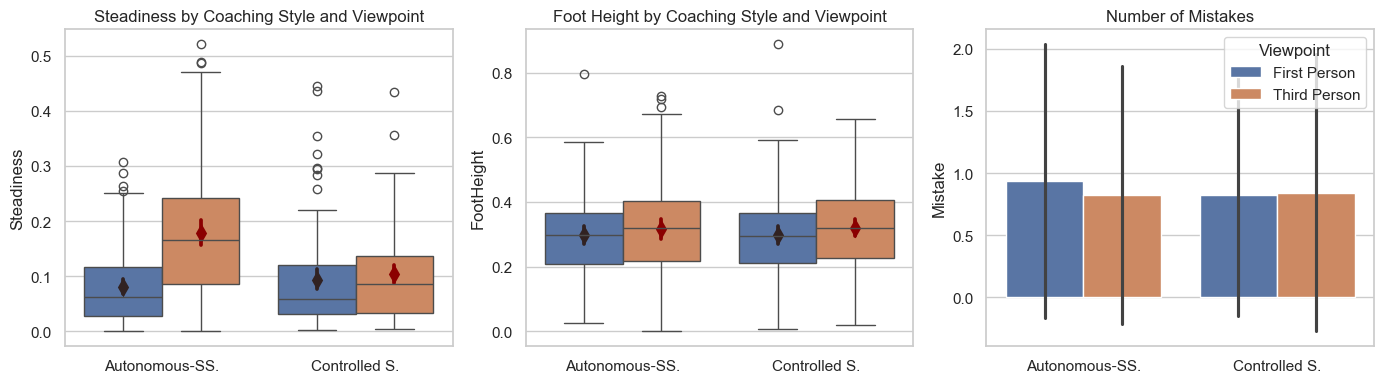

C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\453513912.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


In [56]:
# Visualizations – User performance
user_perf["CoachingStyleName"] = (
    user_perf["CoachingStyle"]
    .replace({
        "Autonomous Style": "Autonomous-SS.",
        "Autonomous-Supportive Style": "Autonomous-SS.",
        "Controlling Style": "Controlled S.",
        "Controlled Style": "Controlled S."
    })
)

plt.figure(figsize=(14, 4))

# Steadiness boxplot
plt.subplot(1, 3, 1)
sns.boxplot(
    data=user_perf,
    x="CoachingStyleName",
    y="Steadiness",
    hue="Viewpoint"
)
sns.pointplot(
    data=user_perf,
    x="CoachingStyleName",
    y="Steadiness",
    hue="Viewpoint",
    dodge=0.4,
    join=False,
    markers="d",
    color="darkred"
)
plt.title("Steadiness by Coaching Style and Viewpoint")
plt.xlabel("")
plt.legend([],[], frameon=False)  # hide duplicate legend here

# FootHeight boxplot
plt.subplot(1, 3, 2)
sns.boxplot(
    data=user_perf,
    x="CoachingStyleName",
    y="FootHeight",
    hue="Viewpoint"
)
sns.pointplot(
    data=user_perf,
    x="CoachingStyleName",
    y="FootHeight",
    hue="Viewpoint",
    dodge=0.4,
    join=False,
    markers="d",
    color="darkred"
)
plt.title("Foot Height by Coaching Style and Viewpoint")
plt.xlabel("")
plt.legend([],[], frameon=False)

# Mistake barplot with error bars
plt.subplot(1, 3, 3)
sns.barplot(
    data=user_perf,
    x="CoachingStyleName",
    y="Mistake",
    hue="Viewpoint",
    ci="sd"
)
plt.title("Number of Mistakes")
plt.xlabel("")

plt.tight_layout()
plt.show()

# single combined legend
plt.figure()
sns.barplot(
    data=user_perf,
    x="CoachingStyleName",
    y="Mistake",
    hue="Viewpoint",
    ci="sd"
)
plt.legend(title="Viewpoint")
plt.close()


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\3907217888.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tlx["TypeName"] = tlx["Type"].replace({
C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\3907217888.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


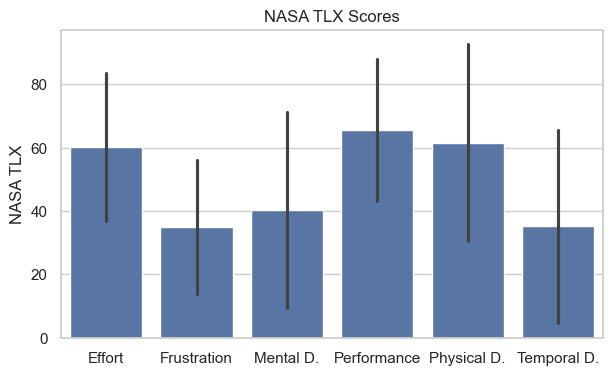

In [57]:
# TLX visualization
tlx["TypeName"] = tlx["Type"].replace({
    "Mental Demand": "Mental D.",
    "Physical Demand": "Physical D.",
    "Temporal Demand": "Temporal D.",
    "Performance": "Performance",
    "Effort": "Effort",
    "Frustration": "Frustration"
})

plt.figure(figsize=(7,4))
sns.barplot(
    data=tlx,
    x="TypeName",
    y="Score",
    ci="sd"
)
plt.title("NASA TLX Scores")
plt.xlabel("")
plt.ylabel("NASA TLX")
plt.show()


C:\Users\Hishaams Desktop\AppData\Local\Temp\ipykernel_19232\3554413725.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


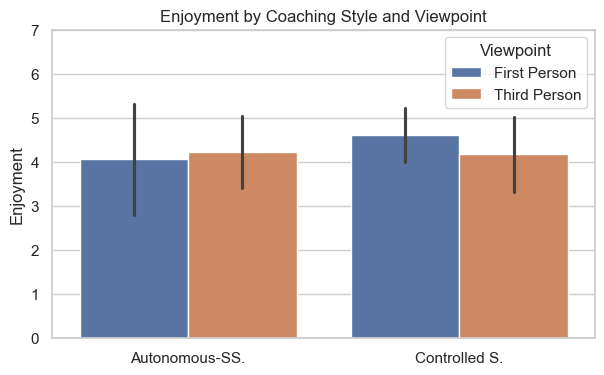

In [58]:
# Mid-questionnaire visualizations
plt.figure(figsize=(7,4))
sns.barplot(
    data=midq,
    x="Coaching.Style",
    y="Enjoyment",
    hue="Viewpoint",
    ci="sd"
)
plt.ylim(0, 7)
plt.title("Enjoyment by Coaching Style and Viewpoint")
plt.xlabel("")
plt.ylabel("Enjoyment")
plt.show()
